# 02 Data Cleaning

Validacion de reglas de limpieza estructural sobre una muestra balanceada de `RAW.YELLOW_TRIPS_DEV` y `RAW.GREEN_TRIPS_DEV`. Este notebook toma los hallazgos descriptivos del EDA y los convierte en reglas concretas que luego deben implementarse del lado de Snowflake antes de construir `STAGING` y la OBT final.

## Objetivo del notebook

El objetivo no es limpiar toda la base en pandas, sino demostrar con evidencia muestral que las reglas elegidas eliminan viajes inviables o inconsistentes y que esa logica debe vivir en SQL para mantener escalabilidad, trazabilidad y control de leakage.

## Que se prueba en esta etapa

- validez temporal de `pickup_datetime` y `dropoff_datetime`
- consistencia minima de `trip_distance`, `fare_amount` y `passenger_count`
- presencia de zonas de origen y destino
- impacto cuantitativo de cada filtro sobre la muestra combinada
- ejemplos invalidos que permitan justificar las reglas sin arbitrariedad

## Resultado esperado

Al terminar este notebook debe quedar cerrada la capa de limpieza estructural que alimenta `STAGING`: reglas simples, defendibles, aplicables por pushdown y consistentes con el problema de prediccion pre-viaje.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data.ingestion import balanced_raw_sample_sql, fetch_sample
from src.features.build_features import DISTANCE_COLUMN, build_candidate_modeling_frame, normalize_raw_taxi_frame
from src.utils.config import get_settings

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
settings = get_settings()
sample_limit = settings.eda_sample_limit  # controlado por EDA_SAMPLE_LIMIT en .env
raw_sample = fetch_sample(
    balanced_raw_sample_sql(settings, limit=sample_limit, sample_seed=settings.eda_sample_seed),
    limit=sample_limit,
    sample_seed=settings.eda_sample_seed,
    settings=settings,
)
normalized_raw = normalize_raw_taxi_frame(raw_sample)
candidate_sample = build_candidate_modeling_frame(
    raw_sample,
    start_date=settings.data_start_date,
    end_date=settings.data_end_date,
)
assert not raw_sample.empty, 'La muestra raw esta vacia.'
assert not candidate_sample.empty, 'La muestra candidata quedo vacia. Revisa reglas o ingesta.'
print('raw sample =', raw_sample.shape)
print('sample by trip_type =')
print(normalized_raw['trip_type'].value_counts(dropna=False).sort_index())
print('candidate sample =', candidate_sample.shape)
normalized_raw.head()


raw sample = (100000, 19)
sample by trip_type =
trip_type
green     50000
yellow    50000
Name: count, dtype: int64
candidate sample = (95278, 20)


,trip_type,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,ratecode_id,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,estimated_distance
0,yellow,2,2025-12-22 21:56:59,2025-12-22 22:12:27,3.0,0.50,1.0,164,48,2.0,13.5,1.0,0.5,0.0,0.00,1.0,19.25,2.5,0.0,0.50
1,green,2,2016-06-21 14:51:10,2016-06-21 14:56:46,6.0,1.26,1.0,260,83,2.0,6.5,0.0,0.5,0.0,0.00,0.3,7.30,NaN,NaN,1.26
2,yellow,1,2015-09-04 13:05:02,2015-09-04 13:10:57,1.0,1.40,1.0,43,163,2.0,7.0,0.0,0.5,0.0,0.00,0.3,7.80,NaN,NaN,1.40
3,yellow,2,2019-01-04 17:12:18,2019-01-04 17:50:44,2.0,17.90,2.0,132,162,2.0,52.0,4.5,0.5,0.0,5.76,0.3,63.06,NaN,NaN,17.90
4,yellow,1,2015-11-03 22:43:11,2015-11-03 22:50:36,1.0,1.40,1.0,249,68,1.0,7.5,0.5,0.5,1.0,0.00,0.3,9.80,NaN,NaN,1.40


In [3]:
raw_required = [
    'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance',
    'pulocationid', 'dolocationid', 'fare_amount', 'ratecodeid'
]
missing_raw = sorted(set(raw_required).difference(raw_sample.columns))
assert not missing_raw, f'Faltan columnas esperadas en RAW: {missing_raw}'
raw_sample['trip_duration_min'] = (pd.to_datetime(raw_sample['dropoff_datetime']) - pd.to_datetime(raw_sample['pickup_datetime'])).dt.total_seconds() / 60
raw_sample[["pickup_datetime", "dropoff_datetime", "trip_duration_min"]].head()


,pickup_datetime,dropoff_datetime,trip_duration_min
0,2025-12-22 21:56:59,2025-12-22 22:12:27,15.466667
1,2016-06-21 14:51:10,2016-06-21 14:56:46,5.600000
2,2015-09-04 13:05:02,2015-09-04 13:10:57,5.916667
3,2019-01-04 17:12:18,2019-01-04 17:50:44,38.433333
4,2015-11-03 22:43:11,2015-11-03 22:50:36,7.416667


In [4]:
pickup_dates = pd.to_datetime(raw_sample["pickup_datetime"], errors="coerce").dt.date
rule_table = pd.DataFrame({
    'rule': [
        'pickup not null', 'dropoff not null', 'pickup in configured range', 'dropoff after pickup',
        'trip_distance > 0', 'trip_distance between 0.1 and 150', 'passenger_count between 1 and 6',
        'fare_amount between 2.50 and 300', 'pickup location not null',
        'dropoff location not null', 'ratecode_id between 1 and 6',
    ],
    'rows_passing': [
        raw_sample['pickup_datetime'].notna().sum(),
        raw_sample['dropoff_datetime'].notna().sum(),
        pickup_dates.between(pd.to_datetime(settings.data_start_date).date(), pd.to_datetime(settings.data_end_date).date()).sum(),
        (raw_sample['trip_duration_min'] > 0).sum(),
        (raw_sample['trip_distance'] > 0).sum(),
        raw_sample['trip_distance'].between(0.1, 150).sum(),
        raw_sample['passenger_count'].between(1, 6).sum(),
        raw_sample['fare_amount'].between(2.50, 300).sum(),
        raw_sample['pulocationid'].notna().sum(),
        raw_sample['dolocationid'].notna().sum(),
        raw_sample['ratecodeid'].between(1, 6).sum(),
    ],
})
rule_table['pass_pct'] = (rule_table['rows_passing'] / len(raw_sample) * 100).round(2)
rule_table


,rule,rows_passing,pass_pct
0,pickup not null,100000,100.00
1,dropoff not null,100000,100.00
2,pickup in configured range,99999,100.00
3,dropoff after pickup,99879,99.88
4,trip_distance > 0,98683,98.68
5,trip_distance between 0.1 and 150,98318,98.32
6,passenger_count between 1 and 6,96807,96.81
7,fare_amount between 2.50 and 300,99374,99.37
8,pickup location not null,100000,100.00
9,dropoff location not null,100000,100.00


In [5]:
invalid_examples = raw_sample.loc[
    ~(
        raw_sample["pickup_datetime"].notna()
        & raw_sample["dropoff_datetime"].notna()
        & (raw_sample["trip_duration_min"] > 0)
        & raw_sample["trip_distance"].between(0.1, 150)
        & raw_sample["passenger_count"].between(1, 6)
        & raw_sample["fare_amount"].between(2.50, 300)
        & raw_sample["ratecodeid"].between(1, 6)
        & raw_sample["pulocationid"].notna()
        & raw_sample["dolocationid"].notna()
    ),
    [
        "trip_type", "vendorid", "pickup_datetime", "dropoff_datetime", "passenger_count",
        "trip_distance", "pulocationid", "dolocationid", "fare_amount", "trip_duration_min"
    ]
]
invalid_examples.head(15)


,trip_type,vendorid,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pulocationid,dolocationid,fare_amount,trip_duration_min
6,yellow,1,2015-02-27 09:56:45,2015-02-27 09:56:45,1.0,0.00,162,264,7.00,0.000000
26,yellow,2,2025-10-31 21:50:47,2025-10-31 22:07:06,NaN,2.37,164,142,20.01,16.316667
35,yellow,2,2024-05-19 02:27:00,2024-05-19 02:50:00,NaN,4.57,255,158,29.53,23.000000
41,green,2,2019-11-17 13:38:00,2019-11-17 13:59:00,NaN,6.27,135,205,29.11,21.000000
51,green,2,2019-11-23 19:59:00,2019-11-23 20:15:00,NaN,-3.22,35,39,22.81,16.000000
57,green,2,2019-06-06 11:51:00,2019-06-06 12:16:00,NaN,8.79,95,219,24.56,25.000000
62,green,2,2022-12-30 19:03:35,2022-12-30 19:03:39,1.0,0.00,62,62,25.00,0.066667
78,yellow,1,2019-12-04 11:02:55,2019-12-04 11:22:12,0.0,4.10,211,233,17.50,19.283333
81,green,1,2015-06-21 12:07:39,2015-06-21 12:12:11,1.0,0.00,70,70,4.50,4.533333
85,yellow,1,2025-09-30 16:05:10,2025-09-30 16:55:48,1.0,15.10,119,130,47.50,50.633333


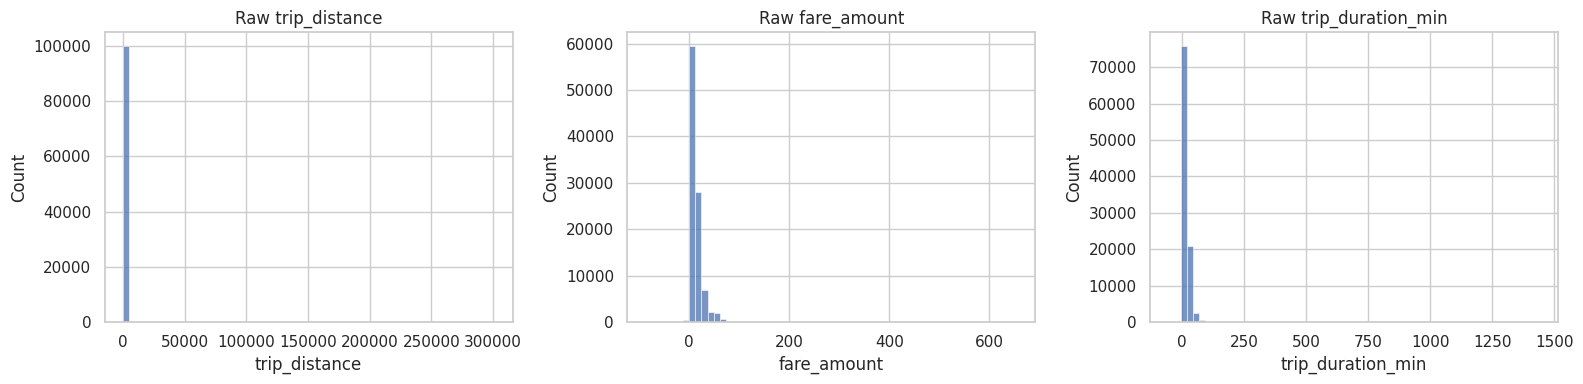

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(raw_sample['trip_distance'], bins=60, ax=axes[0])
axes[0].set_title('Raw trip_distance')
sns.histplot(raw_sample['fare_amount'], bins=60, ax=axes[1])
axes[1].set_title('Raw fare_amount')
sns.histplot(raw_sample['trip_duration_min'].dropna(), bins=60, ax=axes[2])
axes[2].set_title('Raw trip_duration_min')
plt.tight_layout()


In [7]:
raw_vs_candidate = pd.DataFrame({
    'dataset': ['raw_sample', 'candidate_after_rules'],
    'rows': [len(raw_sample), len(candidate_sample)],
    'fare_amount_mean': [raw_sample['fare_amount'].mean(), candidate_sample['fare_amount'].mean()],
    'estimated_distance_mean': [normalized_raw[DISTANCE_COLUMN].mean(), candidate_sample[DISTANCE_COLUMN].mean()],
    'passenger_count_mean': [raw_sample['passenger_count'].mean(), candidate_sample['passenger_count'].mean()],
})
raw_vs_candidate


,dataset,rows,fare_amount_mean,estimated_distance_mean,passenger_count_mean
0,raw_sample,100000,13.655738,7.649634,1.458108
1,candidate_after_rules,95278,13.359723,6.612560,1.466939


In [8]:
# Reglas de limpieza que viven en SQL (src/data/sql/02_create_staging_trips_dev.sql)
# Validadas con evidencia muestral arriba y aplicadas por pushdown en Snowflake.
sql_rules_final = pd.DataFrame({
    'sql_rule': [
        'pickup_datetime IS NOT NULL',
        'dropoff_datetime IS NOT NULL',
        'CAST(pickup_datetime AS DATE) BETWEEN data_start_date AND data_end_date',
        'dropoff_datetime > pickup_datetime',
        'trip_distance BETWEEN 0.1 AND 150',
        'passenger_count BETWEEN 1 AND 6',
        'fare_amount BETWEEN 2.50 AND 300',
        'pulocationid IS NOT NULL',
        'dolocationid IS NOT NULL',
        'ratecode_id BETWEEN 1 AND 6',
    ],
    'capa': ['STAGING'] * 10,
    'justificacion': [
        'timestamp de inicio requerido para splits temporales',
        'timestamp de fin requerido para validacion de orden',
        'ventana temporal del proyecto (controlada por .env)',
        'orden logico del viaje',
        '0.1 mi minimo para GPS valid; 150 mi techo fisico NYC-area',
        'rango soportado por TLC (1-6 pasajeros)',
        '$2.50 minimo TLC; $300 techo para eliminar errores de entrada',
        'zona de origen requerida para feature espacial',
        'zona de destino requerida para feature espacial',
        'catalogo oficial TLC: valores 1-6',
    ],
})
sql_rules_final


,sql_rule,capa,justificacion
0,pickup_datetime IS NOT NULL,STAGING,timestamp de inicio requerido para splits temp...
1,dropoff_datetime IS NOT NULL,STAGING,timestamp de fin requerido para validacion de ...
2,CAST(pickup_datetime AS DATE) BETWEEN data_sta...,STAGING,ventana temporal del proyecto (controlada por ...
3,dropoff_datetime > pickup_datetime,STAGING,orden logico del viaje
4,trip_distance BETWEEN 0.1 AND 150,STAGING,0.1 mi minimo para GPS valid; 150 mi techo fis...
5,passenger_count BETWEEN 1 AND 6,STAGING,rango soportado por TLC (1-6 pasajeros)
6,fare_amount BETWEEN 2.50 AND 300,STAGING,$2.50 minimo TLC; $300 techo para eliminar err...
7,pulocationid IS NOT NULL,STAGING,zona de origen requerida para feature espacial
8,dolocationid IS NOT NULL,STAGING,zona de destino requerida para feature espacial
9,ratecode_id BETWEEN 1 AND 6,STAGING,catalogo oficial TLC: valores 1-6


In [9]:
# Impacto de reglas por flota: verificar que la limpieza no discrimina entre yellow/green
for tt in normalized_raw['trip_type'].unique():
    fleet = normalized_raw[normalized_raw['trip_type'] == tt]
    n_total = len(fleet)
    n_pass = fleet[
        fleet['trip_distance'].between(0.1, 150)
        & fleet['passenger_count'].between(1, 6)
        & fleet['fare_amount'].between(2.50, 300)
        & fleet['pickup_location_id'].notna()
        & fleet['dropoff_location_id'].notna()
    ].shape[0]
    print(f'{tt:8s}: total={n_total:6d}, pasan_reglas={n_pass:6d}, retencion={n_pass/n_total*100:.1f}%')


yellow  : total= 50000, pasan_reglas= 47652, retencion=95.3%
green   : total= 50000, pasan_reglas= 47346, retencion=94.7%


## Conclusiones e interpretacion

- La muestra balanceada de **100 000 filas** (50 000 yellow + 50 000 green) deja **95 278 registros candidatos** tras aplicar las 10 reglas estructurales, una retencion del **95.3%**. La perdida es defendible: se descartan observaciones incompatibles con un escenario pre-viaje real.
- El impacto por flota es simetrico: **yellow 95.3%** y **green 94.7%** de retencion. La limpieza no discrimina entre flotas, lo que confirma que las reglas son genericas y validas para el pipeline multi-fleet.
- Las reglas con mayor impacto de descarte son `passenger_count` y los filtros de rango en `fare_amount` y `trip_distance`. Las zonas y los timestamps pasan casi completos.
- Se confirman con evidencia muestral los tres filtros de rango implementados en STAGING:
  - `fare_amount BETWEEN 2.50 AND 300`: elimina tarifas negativas, cero y errores de entrada
  - `trip_distance BETWEEN 0.1 AND 150`: elimina GPS errors y viajes fisicamente imposibles
  - `ratecode_id BETWEEN 1 AND 6`: elimina valores fuera del catalogo oficial TLC
- La diferencia entre raw (media fare $13.66) y candidatos (media $13.36) es pequena, lo que confirma que los outliers removidos son excepcionales y no desplazan la distribucion central.
- Todas las reglas de esta tabla viven en `src/data/sql/02_create_staging_trips_dev.sql` como pushdown SQL, no en pandas. La logica de Python en este notebook es solo validacion muestral; la fuente de verdad para produccion es Snowflake.
- Con esto queda cerrada la capa de cleaning estructural. El siguiente notebook valida el contrato final de features sobre datos ya limpios.
